In [39]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def load_and_concat_csvs(file_list: list,
                         folder_path: str = "./shifted_datasets/fft_shift/") -> pd.DataFrame:
    dfs = []
    for idx, filename in enumerate(file_list):
        filepath = f"{folder_path}{filename}"
        df = pd.read_csv(filepath)
        df.fillna(0, inplace=True)
        df['dataset_number'] = idx
        dfs.append(df)
    combined = pd.concat(dfs, ignore_index=True)
    combined.fillna(0, inplace=True)
    combined.sort_values(by="Time", inplace=True)
    return combined


def filter_and_rename(df: pd.DataFrame) -> pd.DataFrame:
    keep_prefixes = ('Time', 'car', 'truck', 'history', 'BC', 'dataset_number', 'is_simulated')
    cols = [c for c in df.columns if c.startswith(keep_prefixes)]
    df = df[cols]
    rename_map = {
        'car_line1': 'LDPV_1', 'car_line1_stop': 'StopLDPV_1',
        'car_line2': 'LDPV_2', 'car_line2_stop': 'StopLDPV_2',
        'car_line3': 'LDPV_3', 'car_line3_stop': 'StopLDPV_3',
        'truck_line1': 'HDV_1', 'truck_line2': 'HDV_2', 'truck_line2_stop': 'StopHDV_2',
        'truck_line3': 'HDV_3', 'truck_line3_stop': 'StopHDV_3',
        'history_temperature': 'his_temp',
        'history_wind_speed': 'his_wind',
        'history_humidity': 'his_humid'
    }
    df.rename(columns=rename_map, inplace=True)
    return df


def apply_ci_trim(df: pd.DataFrame, col: str) -> pd.DataFrame:
    n_original = len(df)
    mean = df[col].mean()
    sd = df[col].std()

    df_trimmed = df[(df[col] >= mean - 1.96 * sd) & (df[col] <= mean + 1.96 * sd)]
    # trimmed number of rows
    n_trimmed = len(df_trimmed)
    # number removed
    n_removed = n_original - n_trimmed
    # percentage removed
    pct_removed = n_removed / n_original * 100
    print(f"Col: {col}, Removed {n_removed} rows out of {n_original} ({pct_removed:.2f}%) by 95%‐CI trimming.")

    return df_trimmed


def apply_local_ci_trim(df: pd.DataFrame, col: str) -> pd.DataFrame:
    combined_dataframe_cp = df.copy()
    dfs = []
    for grp, df_g in combined_dataframe_cp.groupby('dataset_number'):
        df_g = apply_ci_trim(df_g, col)
        dfs.append(df_g)

    temp = pd.concat(dfs, ignore_index=True)
    temp.fillna(0, inplace=True)
    temp.sort_values(by="Time", inplace=True)
    return temp


def plot_corr_matrix_beautiful(df, figsize=(10, 10)):
    """
    Plots an enhanced correlation matrix of DataFrame df:
    - Larger figure size
    - Black-to-gray colormap
    - Masks upper triangle
    - Annotates each cell with correlation coefficient (2 decimal places)
    - Dynamic text color for readability
    """
    corr = df.select_dtypes(include=['number']).corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.dpi": 300
    })
    # Custom black-to-gray colormap
    cmap = LinearSegmentedColormap.from_list('white_black', ['white', 'black'])

    # Create figure and axes
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    ax.set_facecolor('white')
    im = ax.imshow(np.ma.array(corr, mask=mask), cmap=cmap, vmin=-1, vmax=1)
    ax.grid(False)
    # Annotate lower triangle
    for i in range(len(corr)):
        for j in range(len(corr)):
            if not mask[i, j]:
                val = corr.iloc[i, j]
                ax.text(
                    j, i,
                    f"{val:.2f}",
                    ha='center', va='center',
                    color='white',
                    fontsize=12
                )

    # Set tick labels
    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_yticks(np.arange(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=12)
    ax.set_yticklabels(corr.index, fontsize=12)

    # Title and colorbar styling
    ax.set_title("Correlation Matrix", fontsize=16, pad=16)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()
    plt.savefig("./corr_matrix.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [40]:
FILES_LIST = [
    "3921.csv", "3922.csv", "3925.csv", "3926.csv",
    "3952.csv", "3953.csv", "3977.csv"
]
bc_ona_df = filter_and_rename(load_and_concat_csvs(FILES_LIST))


/var/folders/m1/vr9l19qx6nsdlthzgyb3xqg40000gq/T/ipykernel_42955/1294495778.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns=rename_map, inplace=True)


In [41]:
bc_ona_df.shape

(378, 18)

In [42]:
bc_ona_df.to_csv("./bc_ona_df.csv")

mean: 685.6878306878307
std: 249.709450068749


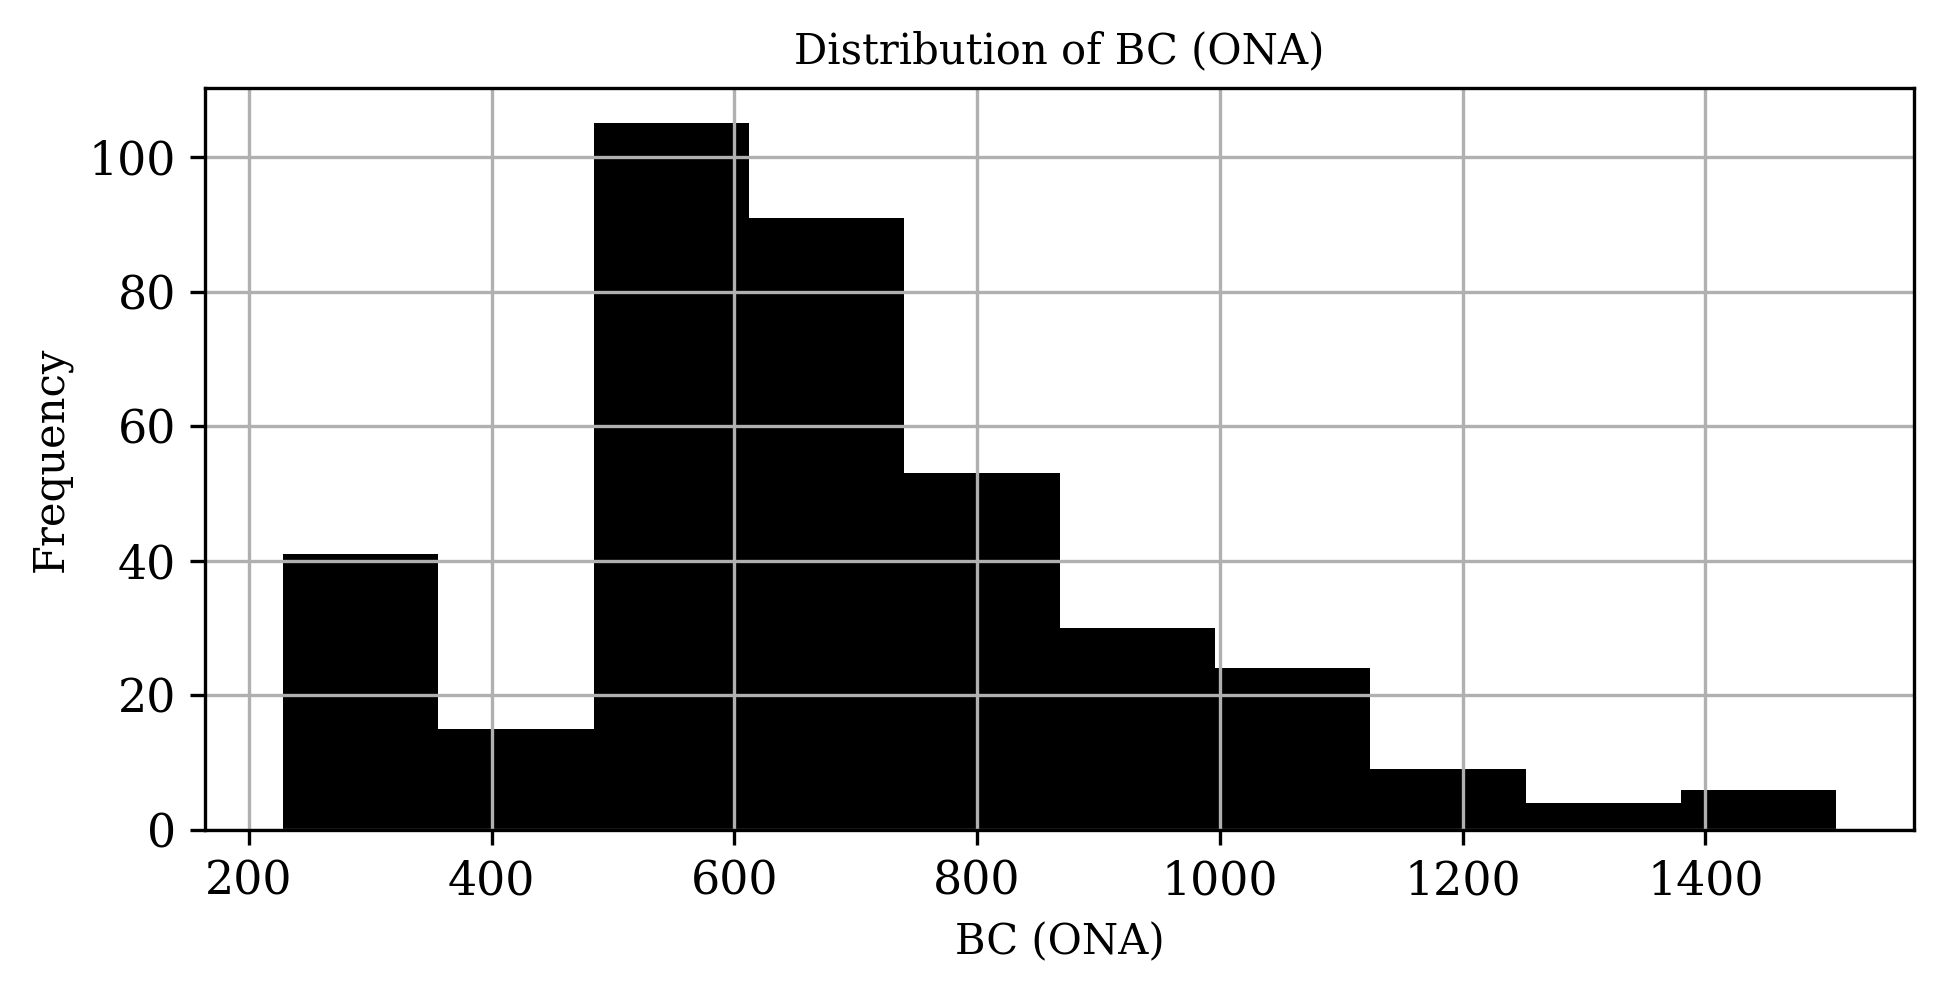

In [44]:
import matplotlib.pyplot as plt

# Update global style (you already have this)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,
    "figure.dpi": 300
})

# Create figure
plt.figure(figsize=(6.58, 3.41))

# Plot histogram with black bars
bc_ona_df['BC post'].hist(color='black')
print("mean:",bc_ona_df['BC post'].mean())
print("std:",bc_ona_df['BC post'].std())
# Add labels/title if desired
plt.xlabel('BC (ONA)')
plt.ylabel('Frequency')
plt.title('Distribution of BC (ONA)')

# Tight layout to avoid clipping
plt.tight_layout()

# Save as PDF
# plt.savefig("bc_post_histogram.pdf", format="pdf", bbox_inches="tight")


In [45]:

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor


def run_experiment(scenario_name, x=None, y=None, random_state=42, X_train=None, X_test=None, y_train=None,
                   y_test=None):
    if X_train is None:
        X_train, X_test, y_train, y_test = train_test_split(
            x, y, test_size=0.25, random_state=random_state
        )
    experiment_memory = {
        "models": {},
        "scenario_name": scenario_name,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }
    models = {
        'LinearRegression': {
            'model': LinearRegression(),
            'params': {}  # No hyperparameters to tune
        },
        'RandomForestRegressor': {
            'model': RandomForestRegressor(random_state=random_state),
            'params': {
                'model__min_samples_split': [2, 5],
                'model__n_estimators': [30, 50, 100, 200],
                'model__max_depth': [None, 5, 6, 7, 9, 10]
            }
        },
        'GradientBoosting': {
            'model': GradientBoostingRegressor(random_state=random_state),
            'params': {
                    'model__n_estimators': [20, 50, 100, 200, 250],
                'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
                'model__max_depth': [3, 5, 6, 7]
            }
        },
        'SVR': {
            'model': SVR(),
            'params': {
                'model__C': [0.1, 1, 10],
                'model__epsilon': [0.01, 0.1, 1]
            }
        },
        'XGBoost': {
            'model': XGBRegressor(random_state=random_state, objective='reg:squarederror'),
            'params': {
                'model__n_estimators': [20, 50, 100, 200, 250],
                'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
                'model__max_depth': [3, 5, 6, 7]
            }
        }
    }

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, test_idx = next(cv.split(pd.concat([X_train,X_test]), pd.concat([y_train,y_test])))

    n_train = train_idx.shape[0]
    n_test  = test_idx.shape[0]

    print(f"Samples per fold: train = {n_train}, test = {n_test}")
    for name, config in models.items():
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', config['model'])
        ])

        grid = GridSearchCV(
            pipeline,
            config['params'],
            cv=cv,
            scoring='r2',
            n_jobs=-1,
            return_train_score=False
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_

        # --- TEST SET PREDICTIONS & METRICS ---
        y_test_pred = best_model.predict(X_test)

        r2_test = r2_score(y_test, y_test_pred)
        mse_test = mean_squared_error(y_test, y_test_pred)
        rmse_test = np.sqrt(mse_test)

        # --- TRAIN SET PREDICTIONS & METRICS ---
        y_train_pred = best_model.predict(X_train)
        mse_train = mean_squared_error(y_train, y_train_pred)
        rmse_train = np.sqrt(mse_train)

        # extract CV fold‐scores for the chosen param set
        best_idx = grid.best_index_
        cv_scores = [
            grid.cv_results_[f"split{i}_test_score"][best_idx]
            for i in range(cv.get_n_splits())
        ]
        experiment_memory["models"][name] = {
            'best_params': grid.best_params_,
            'r2_test': r2_test,
            'mse_test': mse_test,
            'rmse_test': rmse_test,
            'mse_train': mse_train,
            'rmse_train': rmse_train,
            'best_estimator': best_model,
            'cv_scores': cv_scores,
            "test_predictions": y_test_pred
        }
    experiment_memory['best_model_name'] = max(experiment_memory["models"],
                                               key=lambda k: experiment_memory["models"][k]['r2_test'])

    return experiment_memory


In [46]:
train, test, = train_test_split(
    bc_ona_df, test_size=0.25, random_state=42, stratify=bc_ona_df['dataset_number']
)


In [47]:
bc_ona_general_trimmed = apply_ci_trim(train, 'BC post')
bc_ona_local_trimmed = apply_local_ci_trim(train, 'BC post')

bc_general_trimmed = apply_ci_trim(train, 'BC')
bc_local_trimmed = apply_local_ci_trim(train, 'BC')

Col: BC post, Removed 12 rows out of 283 (4.24%) by 95%‐CI trimming.
Col: BC post, Removed 1 rows out of 31 (3.23%) by 95%‐CI trimming.
Col: BC post, Removed 2 rows out of 42 (4.76%) by 95%‐CI trimming.
Col: BC post, Removed 1 rows out of 106 (0.94%) by 95%‐CI trimming.
Col: BC post, Removed 2 rows out of 40 (5.00%) by 95%‐CI trimming.
Col: BC post, Removed 2 rows out of 21 (9.52%) by 95%‐CI trimming.
Col: BC post, Removed 3 rows out of 28 (10.71%) by 95%‐CI trimming.
Col: BC post, Removed 1 rows out of 15 (6.67%) by 95%‐CI trimming.
Col: BC, Removed 14 rows out of 283 (4.95%) by 95%‐CI trimming.
Col: BC, Removed 1 rows out of 31 (3.23%) by 95%‐CI trimming.
Col: BC, Removed 2 rows out of 42 (4.76%) by 95%‐CI trimming.
Col: BC, Removed 2 rows out of 106 (1.89%) by 95%‐CI trimming.
Col: BC, Removed 4 rows out of 40 (10.00%) by 95%‐CI trimming.
Col: BC, Removed 2 rows out of 21 (9.52%) by 95%‐CI trimming.
Col: BC, Removed 2 rows out of 28 (7.14%) by 95%‐CI trimming.
Col: BC, Removed 1 row

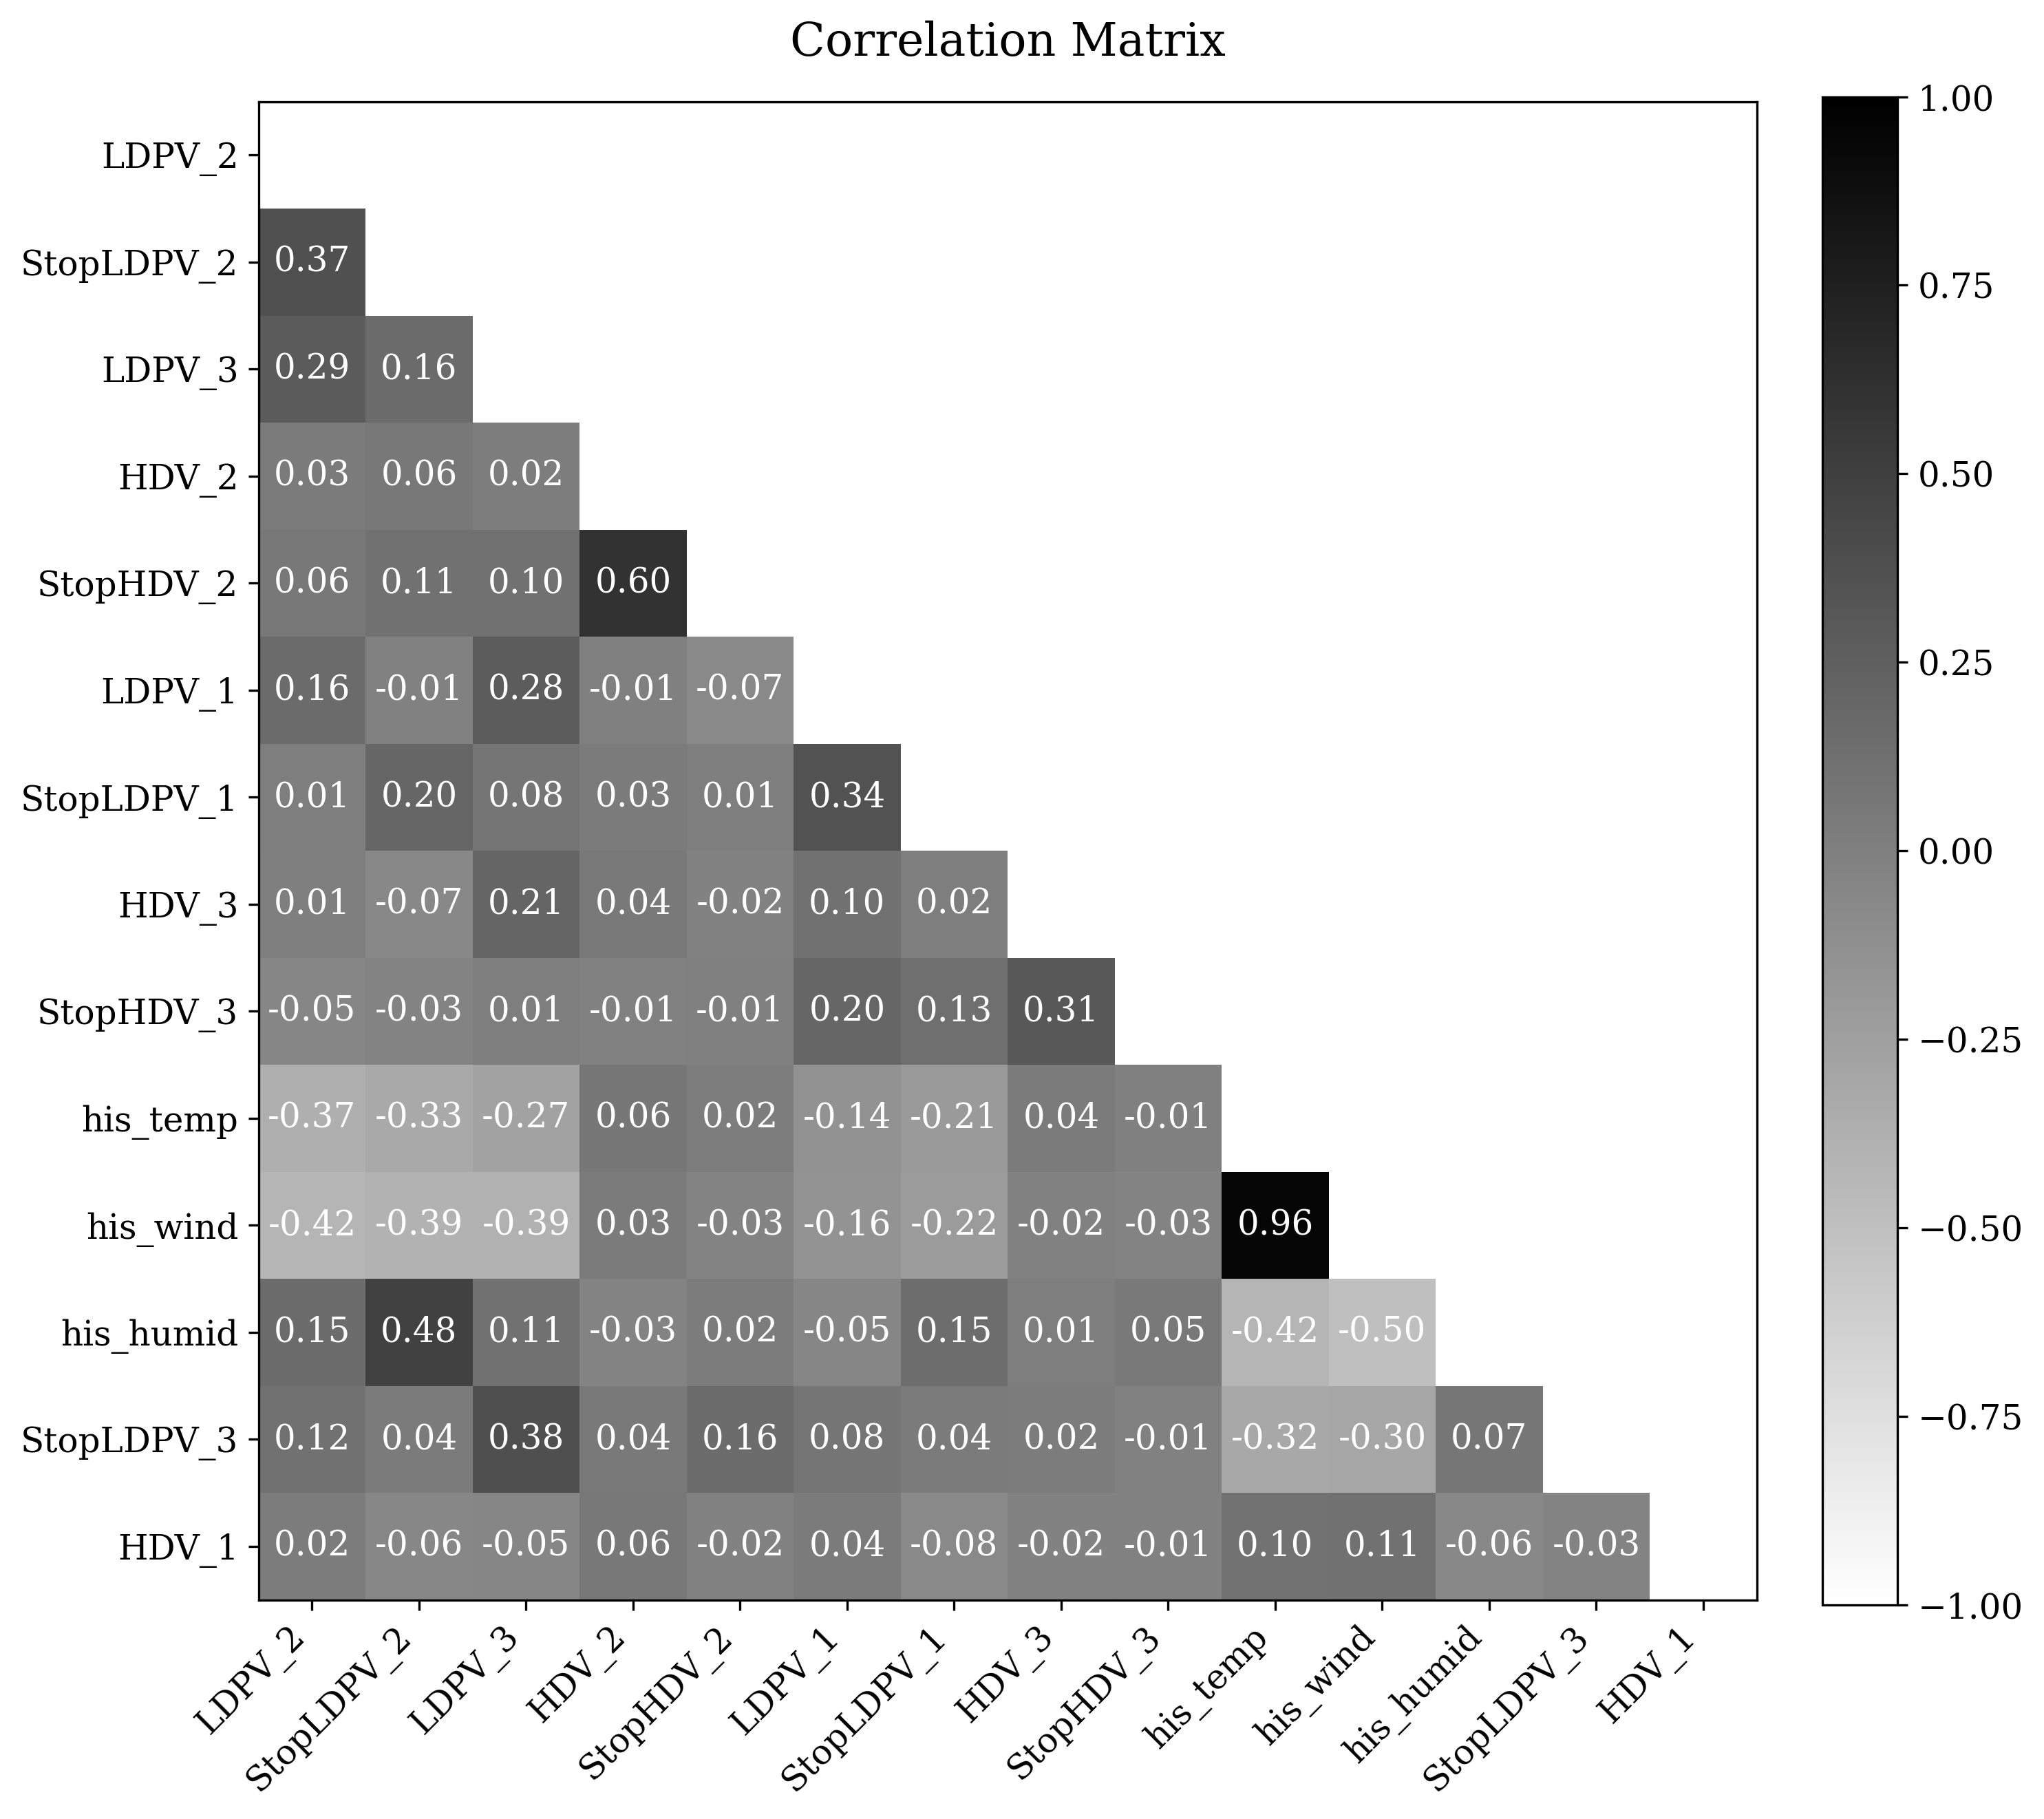

In [48]:

temp = bc_ona_local_trimmed
temp = temp.drop(columns=["BC","BC post","dataset_number"])
plot_corr_matrix_beautiful(temp)

In [49]:


scenarios = {
    "BC": {
        'drop_from_x': ['BC', 'BC post', 'Time', 'dataset_number', 'his_temp'],
        "train": train,
        "target_y": 'BC',
    },
    "BC General Trimmed": {
        'drop_from_x': ['BC', 'BC post', 'Time','StopHDV_3', 'dataset_number', 'his_temp'],
        "train": bc_general_trimmed,
        "target_y": 'BC',
    },
    "BC Local Trimmed": {
        'drop_from_x': ['BC', 'BC post', 'Time', 'dataset_number', 'his_temp'],
        "train": bc_local_trimmed,
        "target_y": 'BC',
    },
    "ONA": {
        'drop_from_x': ['BC', 'BC post', 'Time', 'dataset_number', 'his_temp'],
        "train": train,
        "target_y": 'BC post',
    },
    "ONA General Trimmed": {
        'drop_from_x': ['BC', 'BC post', 'StopHDV_3', 'Time', 'dataset_number', 'his_temp'],
        "train": bc_ona_general_trimmed,
        "target_y": 'BC post',
    },
    "ONA Local Trimmed": {
        'drop_from_x': ['BC', 'BC post', 'Time', 'dataset_number', 'his_temp'],
        "train": bc_ona_local_trimmed,
        "target_y": 'BC post',
    }
}



In [50]:
for i, scenario in enumerate(scenarios):
    temp = scenarios[scenario]
    scenarios[scenario]['results'] = run_experiment(scenario, X_train=temp['train'].drop(columns=temp['drop_from_x']),
                                                    X_test=test.drop(columns=temp['drop_from_x']),
                                                    y_train=temp['train'][temp['target_y']],
                                                    y_test=test[temp['target_y']],
                                                    random_state=42)


Samples per fold: train = 302, test = 76
Samples per fold: train = 291, test = 73
Samples per fold: train = 291, test = 73
Samples per fold: train = 302, test = 76
Samples per fold: train = 292, test = 74
Samples per fold: train = 292, test = 74


In [35]:
just_best = {}
for scenario in scenarios:
    selected = scenarios[scenario]
    print(" ----------scenario: ", scenario, " ----------")
    for model in selected['results']['models']:
        print("model: ", model)
        print("r2_test:", selected['results']['models'][model]['r2_test'], " ,mse_test:",
              selected['results']['models'][model]['mse_test']
              , " ,rmse_test:", selected['results']['models'][model]['rmse_test']
              , " ,mse_train:", selected['results']['models'][model]['mse_train']
              , " ,rmse_train:", selected['results']['models'][model]['rmse_train'])
    print("Best Model:", selected['results']['best_model_name'], " R2: ",
          selected['results']['models'][selected['results']['best_model_name']]['r2_test']," best_params: ",selected['results']['models'][selected['results']['best_model_name']]['best_params'])
    just_best[scenario] = selected['results']['models'][selected['results']['best_model_name']]


 ----------scenario:  BC  ----------
model:  LinearRegression
r2_test: 0.18837357827156365  ,mse_test: 72255.88655564535  ,rmse_test: 268.80455084623355  ,mse_train: 52234.11797334701  ,rmse_train: 228.54784613587373
model:  RandomForestRegressor
r2_test: 0.5312226695900533  ,mse_test: 41733.38952399539  ,rmse_test: 204.28751680901942  ,mse_train: 26169.538399463778  ,rmse_train: 161.7700169977854
model:  GradientBoosting
r2_test: 0.48235229965752546  ,mse_test: 46084.12504866841  ,rmse_test: 214.67213384291034  ,mse_train: 30409.423675821377  ,rmse_train: 174.38297989144863
model:  SVR
r2_test: 0.05372662335242717  ,mse_test: 84242.97179491259  ,rmse_test: 290.24639841850336  ,mse_train: 71322.72092338538  ,rmse_train: 267.0631403308689
model:  XGBoost
r2_test: 0.49291331987711506  ,mse_test: 45143.91923664783  ,rmse_test: 212.47098445822627  ,mse_train: 25259.001424268663  ,rmse_train: 158.9308070333397
Best Model: RandomForestRegressor  R2:  0.5312226695900533  best_params:  {'model

In [36]:
bst_name = max(just_best, key=lambda k: just_best[k]['r2_test'])
print(bst_name)
best = scenarios[bst_name]['results']


best_X_test = best['X_test']
best_y_test = best['y_test']
test_set = test
test_set['is_simulated'] = 0
test_set['is_test'] = 1
train_set = scenarios[bst_name]['train']
train_set['is_simulated'] = 0
train_set['is_test'] = 0

ONA Local Trimmed


/Users/aryansadeghi/PyCharmMiscProject/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


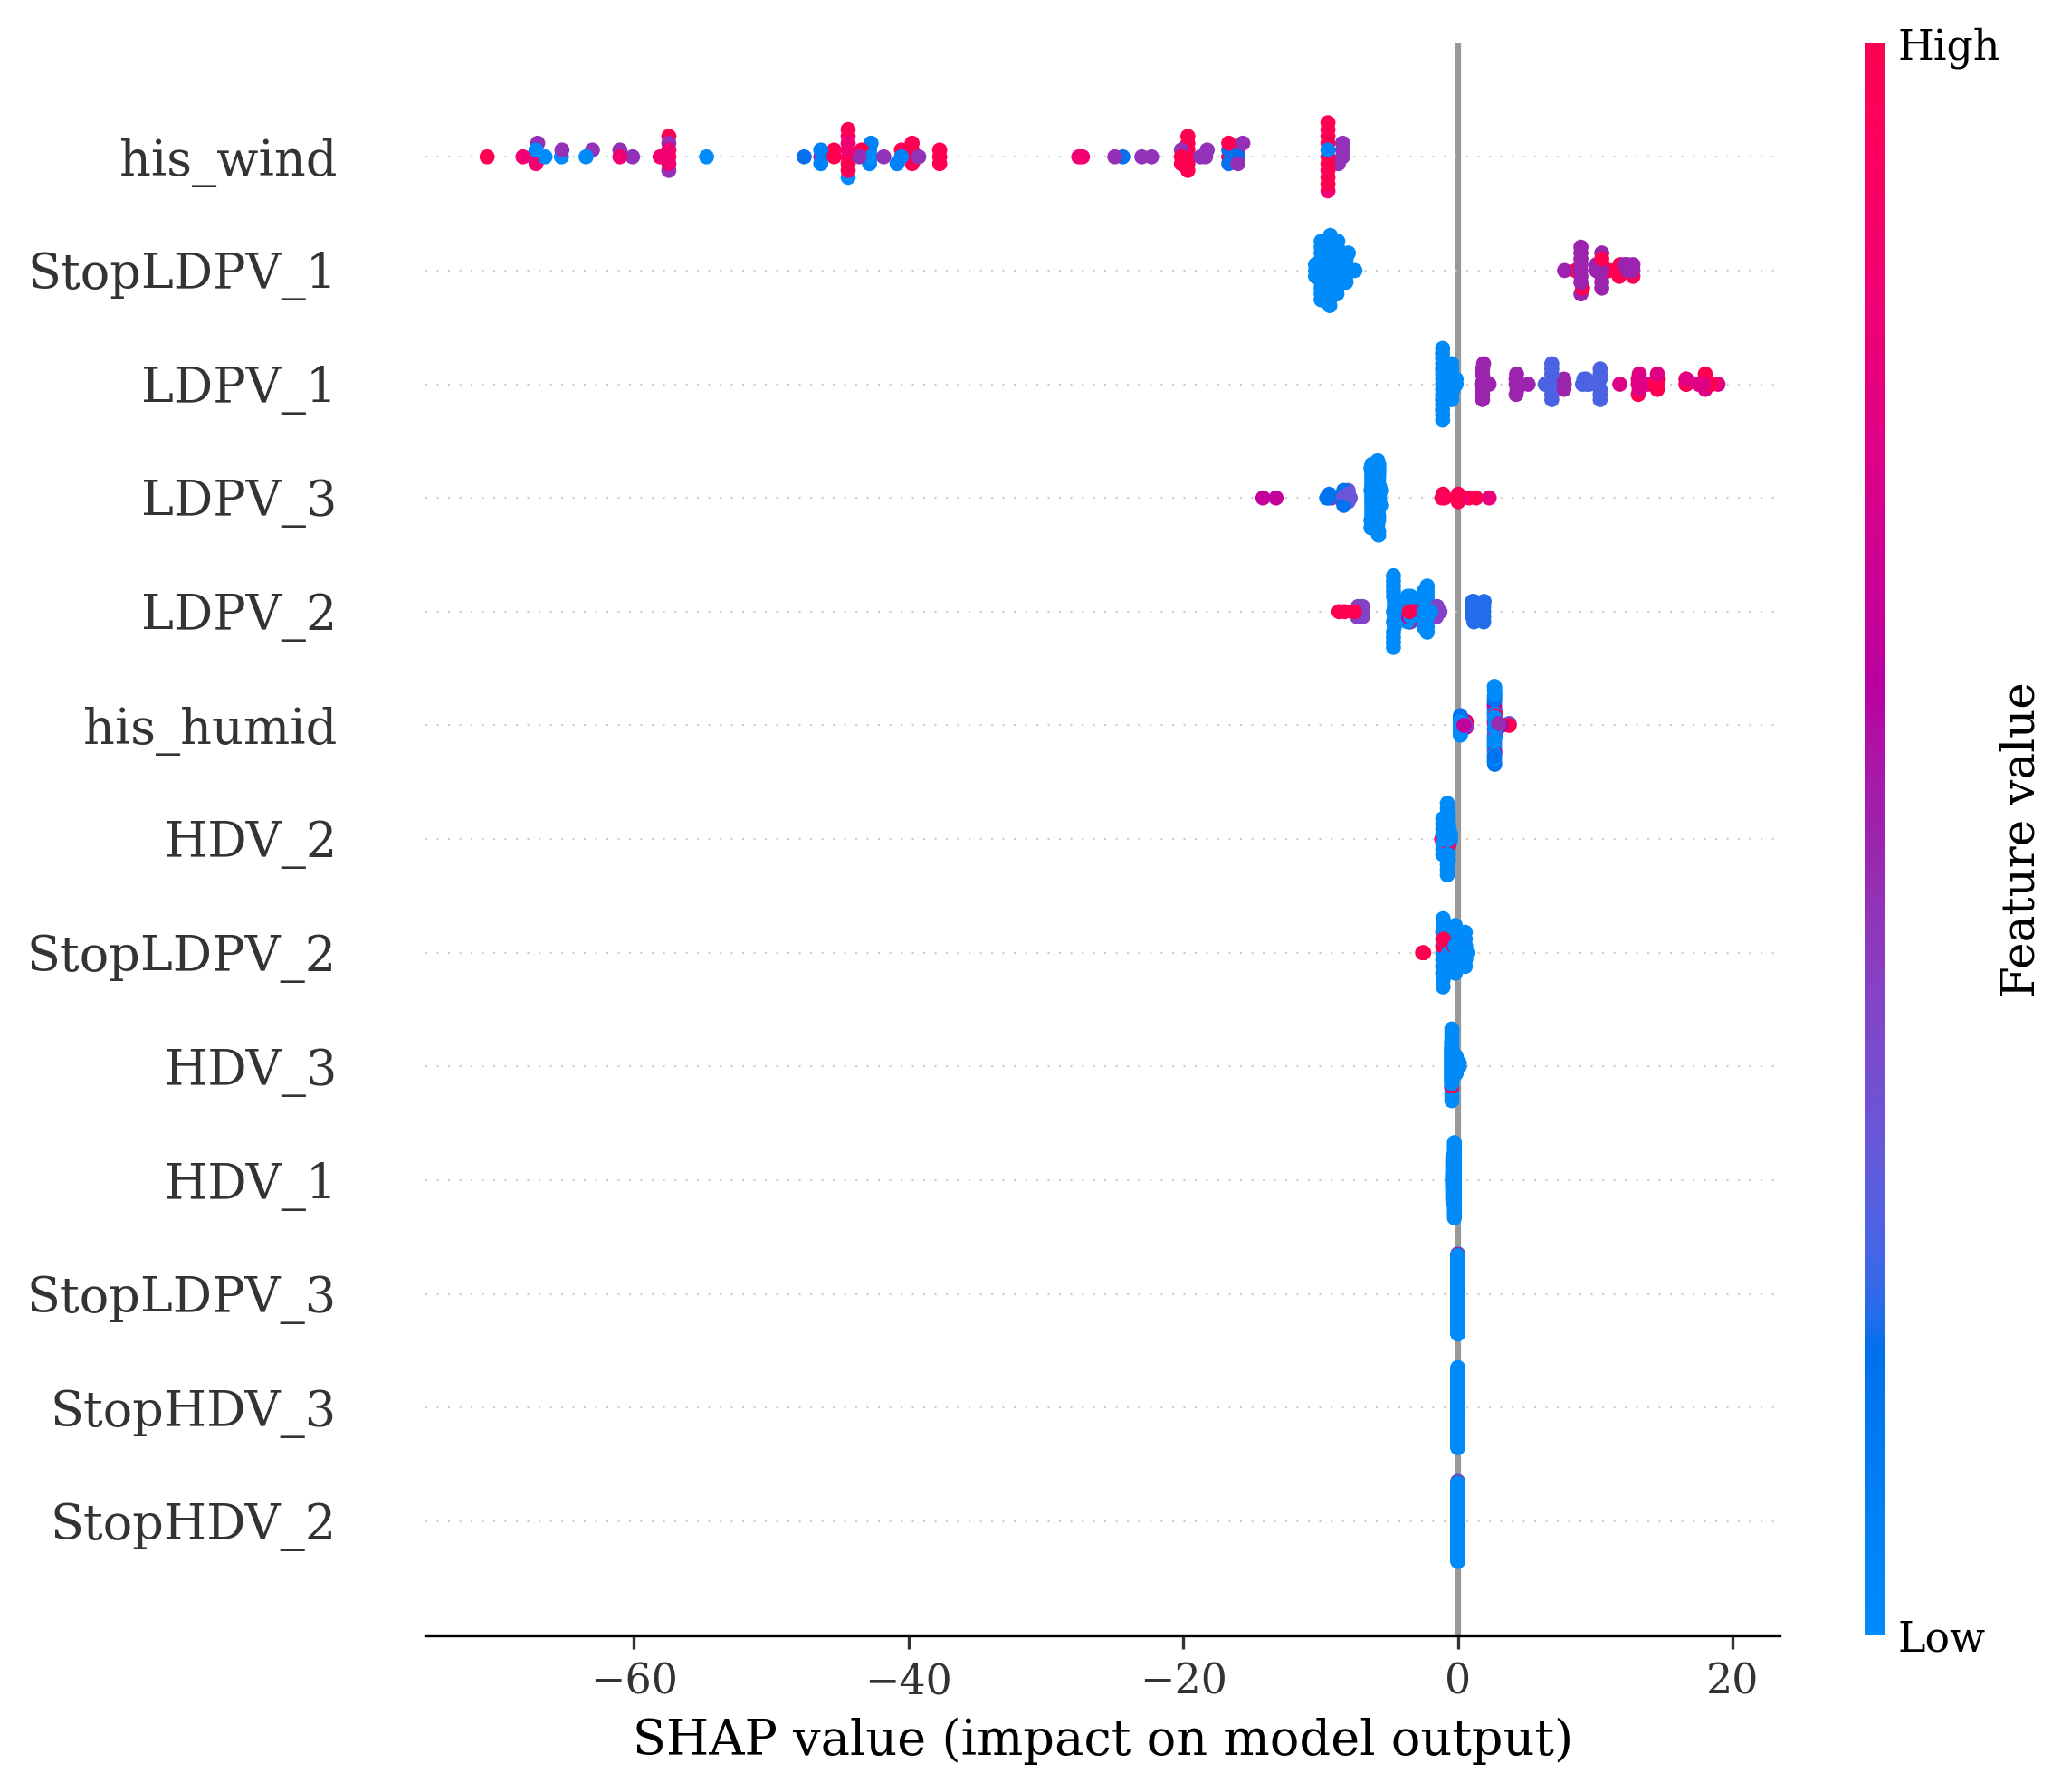

In [37]:
import shap
import matplotlib.pyplot as plt
plt.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.dpi": 300
    })
# build your explainer and compute shap_values as before
best_model = scenarios[bst_name]['results']['models'][scenarios[bst_name]['results']['best_model_name']]['best_estimator']
explainer = shap.Explainer(best_model.named_steps['model'])
shap_values = explainer(best_X_test)

# 1) Create the summary plot but don't show it yet
shap.summary_plot(shap_values, best_X_test, show=False)

# 2) Tighten layout so labels aren’t cut off
plt.tight_layout()

# 3a) Save as a high-resolution PNG
plt.savefig("shap_summary_plot.pdf", format="pdf",dpi=300, bbox_inches="tight")

# 3b) (Optional) Or save as a scalable vector graphic
plt.savefig("shap_summary_plot.svg", format="svg", bbox_inches="tight")


In [38]:
import pickle
with open('xgboost_model.pkl', 'wb') as f:
        pickle.dump(best_model, f)
